![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

cities = pd.read_csv('/Users/vickywu/Documents/ECO 590 Data Analytics/weekly-task-5-SakurairoKaden/weekly task 5/us-cities-top-1k-multi-year.csv')
jobs = pd.read_csv('/Users/vickywu/Documents/ECO 590 Data Analytics/weekly-task-5-SakurairoKaden/weekly task 5/job-automation-probability.csv')

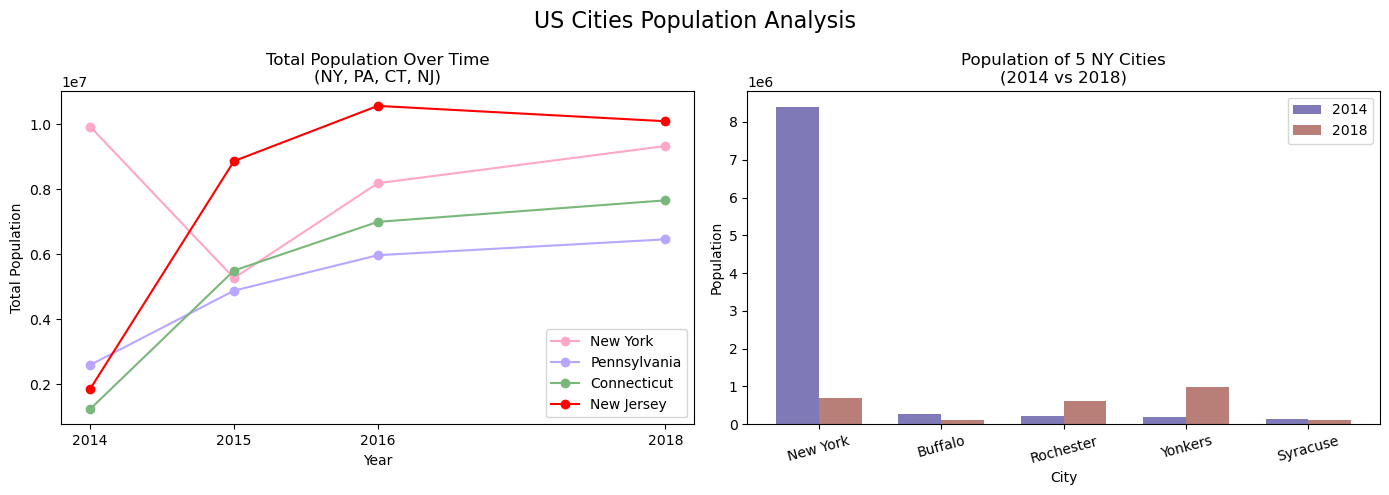

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# ───────── Graph 1: Line Graph ───────────
states = ['New York', 'Pennsylvania', 'Connecticut', 'New Jersey']
state_pop = (cities[cities['State'].isin(states)]
    .groupby(['year', 'State'])['Population']
    .sum()
    .reset_index())

colors = {'New York': '#ffa6c9',
          'Pennsylvania': '#b8a6ff',
          'Connecticut': '#79b87a',
          'New Jersey': 'red'}

ax1 = plt.subplot(1, 2, 1)  # left subplot

for state in states:
    subset = state_pop[state_pop['State'] == state]
    ax1.plot(subset['year'], subset['Population'],
             marker='o', label=state, color=colors[state])

ax1.set_title('Total Population Over Time\n(NY, PA, CT, NJ)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Population')
ax1.legend()
ax1.set_xticks([2014, 2015, 2016, 2018])  # set explicit tick marks

# ───────── Graph 2: Bar Graph ───────────
ny_cities_5 = ['New York', 'Buffalo', 'Rochester', 'Yonkers', 'Syracuse']
ny = cities[(cities['State'] == 'New York') &
            (cities['City'].isin(ny_cities_5)) &
            (cities['year'].isin([2014, 2018]))][['City', 'year', 'Population']]

ny_2014 = ny[ny['year'] == 2014].set_index('City')['Population']
ny_2018 = ny[ny['year'] == 2018].set_index('City')['Population']

import numpy as np
x = np.arange(len(ny_cities_5))  # x positions for the city labels
width = 0.35                      # width of each bar

ax2 = plt.subplot(1, 2, 2)  # right subplot

ax2.bar(x - width/2, ny_2014[ny_cities_5], width,
        label='2014', color='#7f79b8')
ax2.bar(x + width/2, ny_2018[ny_cities_5], width,
        label='2018', color='#b87f79')

ax2.set_title('Population of 5 NY Cities\n(2014 vs 2018)')
ax2.set_xlabel('City')
ax2.set_ylabel('Population')
ax2.set_xticks(x)
ax2.set_xticklabels(ny_cities_5, rotation=15)
ax2.legend()

fig.suptitle('US Cities Population Analysis', fontsize=16)
fig.tight_layout()
plt.show()

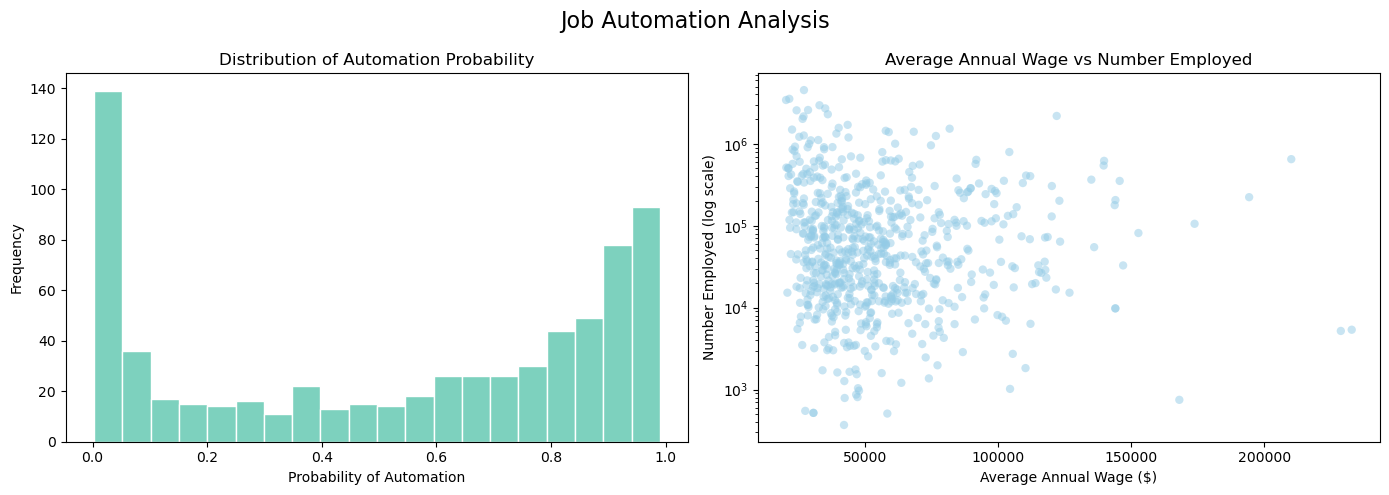

Figure saved as job_automation_analysis.png


In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# ───────── Histogram Graph ───────────
ax1 = plt.subplot(1, 2, 1)
ax1.hist(jobs['probability'], bins=20, color='#7dd1be', edgecolor='white')
ax1.set_title('Distribution of Automation Probability')
ax1.set_xlabel('Probability of Automation')
ax1.set_ylabel('Frequency')

# ───────── Scatterplot Graph ───────────
ax2 = plt.subplot(1, 2, 2)
ax2.scatter(jobs['average_ann_wage'], jobs['numbEmployed'],
            alpha=0.5, color='#93cbe6', edgecolors='none')
ax2.set_yscale('log')

ax2.set_title('Average Annual Wage vs Number Employed')
ax2.set_xlabel('Average Annual Wage ($)')
ax2.set_ylabel('Number Employed (log scale)')

# ───────── Showing the Graphs ───────────
fig.suptitle('Job Automation Analysis', fontsize=16)
fig.tight_layout()

plt.savefig('job_automation_analysis.png', dpi=300, transparent=True)
plt.show()

print('Figure saved as job_automation_analysis.png')